In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path
import sys

In [3]:
sys.path.insert(0, str(Path.cwd().parent))

In [4]:
sys.path

['/Users/ayushsinghsongara/Documents/Development/Jupyter/vs code/MLops/jamboore_education',
 '/opt/anaconda3/lib/python313.zip',
 '/opt/anaconda3/lib/python3.13',
 '/opt/anaconda3/lib/python3.13/lib-dynload',
 '',
 '/Users/ayushsinghsongara/Documents/Development/Jupyter/vs code/MLops/.venv/lib/python3.13/site-packages']

In [5]:
from src.data.loader import load_data
import src.config

In [6]:
df = load_data(path=src.config.RAW_DATA_FILE_PATH)
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [7]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, random_state=42)

In [8]:
train.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
249,250,321,111,3,3.5,4.0,8.83,1,0.77
433,434,316,111,4,4.0,5.0,8.54,0,0.71
19,20,303,102,3,3.5,3.0,8.50,0,0.62
322,323,314,107,2,2.5,4.0,8.27,0,0.72
332,333,308,106,3,3.5,2.5,8.21,1,0.75


In [9]:
train.drop(columns=["Serial No."], inplace=True)
train.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
249,321,111,3,3.5,4.0,8.83,1,0.77
433,316,111,4,4.0,5.0,8.54,0,0.71
19,303,102,3,3.5,3.0,8.50,0,0.62
322,314,107,2,2.5,4.0,8.27,0,0.72
332,308,106,3,3.5,2.5,8.21,1,0.75


In [10]:
train.rename({
    "GRE Score": "GRE_Score",
    "TOEFL Score": "TOEFL_Score",
    "University Rating": "University_Rating",
    "Chance of Admit ": "Chance_of_Admit",
    "LOR ": "LOR"
}, axis=1, inplace=True)
train.head()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
249,321,111,3,3.5,4.0,8.83,1,0.77
433,316,111,4,4.0,5.0,8.54,0,0.71
19,303,102,3,3.5,3.0,8.50,0,0.62
322,314,107,2,2.5,4.0,8.27,0,0.72
332,308,106,3,3.5,2.5,8.21,1,0.75


In [11]:
train.dropna(inplace=True)

In [12]:
train.drop_duplicates(inplace=True)

In [13]:
train.head()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
249,321,111,3,3.5,4.0,8.83,1,0.77
433,316,111,4,4.0,5.0,8.54,0,0.71
19,303,102,3,3.5,3.0,8.50,0,0.62
322,314,107,2,2.5,4.0,8.27,0,0.72
332,308,106,3,3.5,2.5,8.21,1,0.75


In [14]:
from src.data.cleaner import clean_data
df = train.copy()
df.head()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
249,321,111,3,3.5,4.0,8.83,1,0.77
433,316,111,4,4.0,5.0,8.54,0,0.71
19,303,102,3,3.5,3.0,8.50,0,0.62
322,314,107,2,2.5,4.0,8.27,0,0.72
332,308,106,3,3.5,2.5,8.21,1,0.75


In [15]:
df.shape

(400, 8)

In [16]:
X_train = df.drop(columns=['Chance_of_Admit'])
y_train = df['Chance_of_Admit']

In [17]:
X_train.head()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research
249,321,111,3,3.5,4.0,8.83,1
433,316,111,4,4.0,5.0,8.54,0
19,303,102,3,3.5,3.0,8.50,0
322,314,107,2,2.5,4.0,8.27,0
332,308,106,3,3.5,2.5,8.21,1


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprocess = Pipeline([
    ('scaler', StandardScaler())
])

In [19]:
preprocess.fit(X_train)

,steps,"[('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [20]:
X_preprocessed = preprocess.transform(X_train)

In [21]:
X_preprocessed

array([[ 0.38998634,  0.6024183 , -0.09829757, ...,  0.56498381,
         0.4150183 ,  0.89543386],
       [-0.06640493,  0.6024183 ,  0.7754586 , ...,  1.65149114,
        -0.06785154, -1.11677706],
       [-1.25302222, -0.87691722, -0.09829757, ..., -0.52152352,
        -0.13445427, -1.11677706],
       ...,
       [-1.34430047, -1.37002906, -1.8458099 , ..., -1.60803084,
        -2.2157898 , -1.11677706],
       [-0.7053527 , -0.38380538, -0.97205374, ...,  0.56498381,
        -1.49981038, -1.11677706],
       [-0.24896144, -0.21943477, -0.97205374, ...,  0.02173015,
        -0.55072138, -1.11677706]], shape=(400, 7))

In [22]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
linear_model = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

In [23]:
linear_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [24]:
from sklearn.model_selection import RandomizedSearchCV, cross_validate
cv = cross_validate(linear_model, X_train, y_train, cv=5, scoring='r2')

In [25]:
round(cv['test_score'].mean(), 5)

np.float64(0.8079)

In [26]:
ridge_model = Pipeline([
    ('preprocess', preprocess),
    ('model', Ridge())
])

In [27]:
from scipy.stats import uniform

params = {'model__alpha': uniform(loc=5, scale=2)}
rcv = RandomizedSearchCV(
    ridge_model,
    param_distributions=params,
    n_iter=20,
    scoring='r2',
    cv=5,
    n_jobs=-1
)
rcv.fit(X_train, y_train)

,estimator,"Pipeline(step...l', Ridge())])"
,param_distributions,{'model__alpha': <scipy.stats....t 0x14d14d550>}
,n_iter,20
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [28]:
rcv.best_params_

{'model__alpha': np.float64(6.952455089973801)}

In [29]:
rcv.best_score_

np.float64(0.8082727429048233)

In [30]:
lasso_model = Pipeline([
    ('preprocess', preprocess),
    ('model', Lasso())
])

In [31]:
params = {'model__alpha': uniform(loc=0.0, scale=0.01)}
rcv = RandomizedSearchCV(
    lasso_model,
    param_distributions=params,
    n_iter=20,
    scoring='r2',
    cv=5,
    n_jobs=-1
)
rcv.fit(X_train, y_train)

,estimator,"Pipeline(step...l', Lasso())])"
,param_distributions,{'model__alpha': <scipy.stats....t 0x14cb57b10>}
,n_iter,20
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [32]:
rcv.best_params_

{'model__alpha': np.float64(0.00046993594541183903)}

In [33]:
rcv.best_score_

np.float64(0.8084514163238363)

In [34]:
lasso_best = rcv.best_estimator_.fit(X_train, y_train)
lasso_best.score(X_train, y_train)

0.8210484808399999

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [42]:
y_pred = linear_model.predict(X_train)

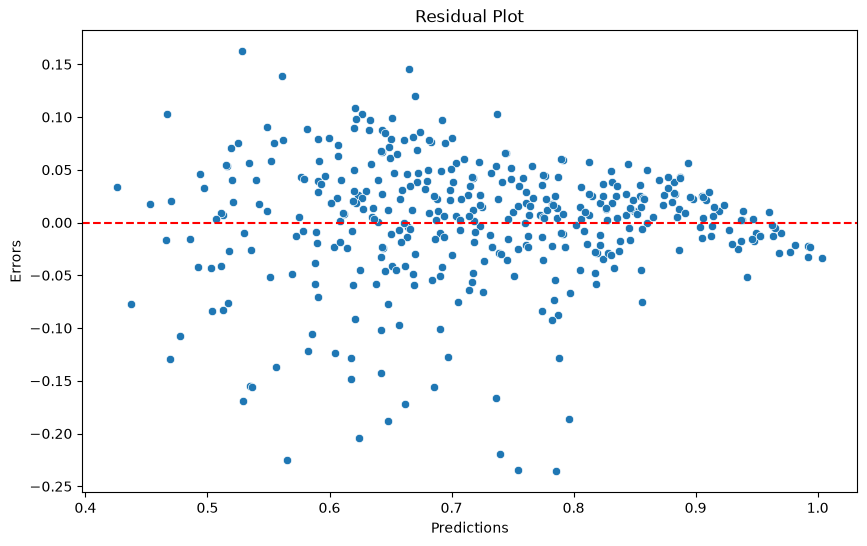

In [84]:
residuals = y_train - y_pred
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.title("Residual Plot")
plt.xlabel("Predictions")
plt.ylabel('Errors')
plt.axhline(0, color='r', linestyle='--')
plt.show()

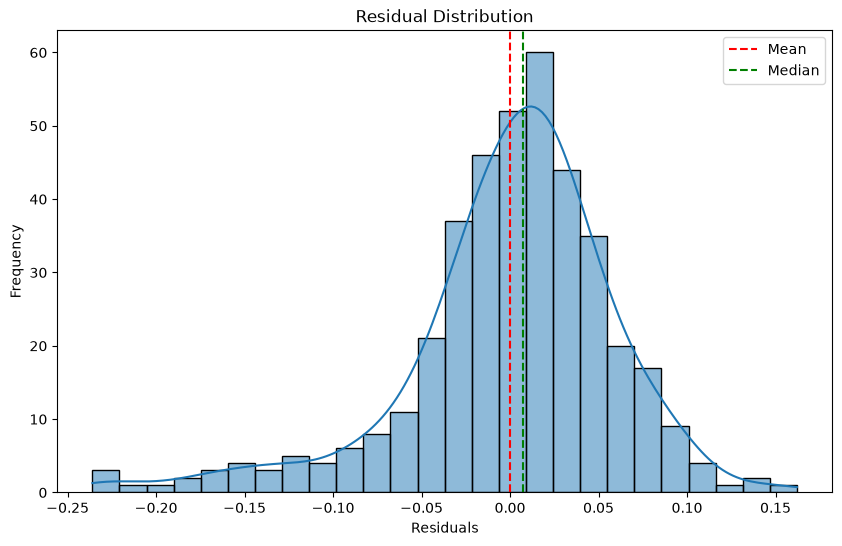

In [83]:
fig = plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.axvline(x=residuals.mean(), color='r', linestyle='--', label="Mean")
plt.axvline(x=residuals.median(), color='g', linestyle='--', label="Median")
plt.legend()
plt.show()

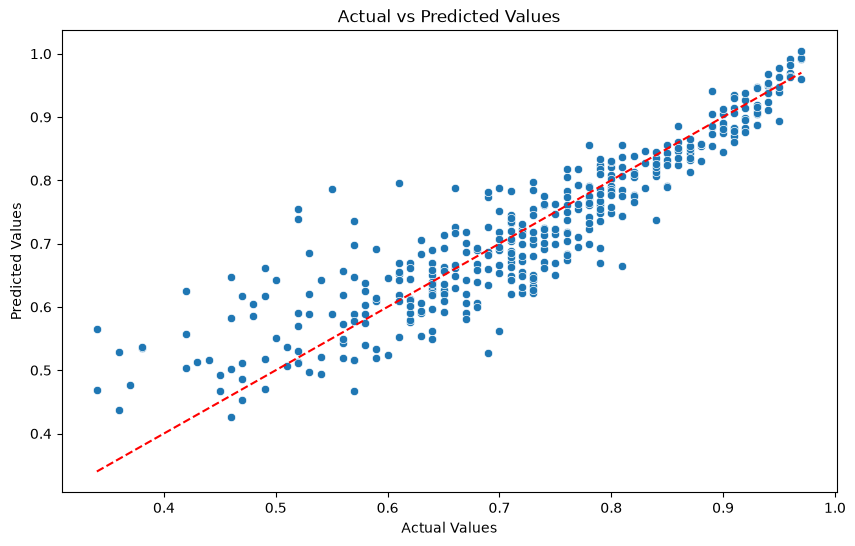

In [72]:
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_train, y=y_pred)
plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='r', linestyle='--')
plt.show()

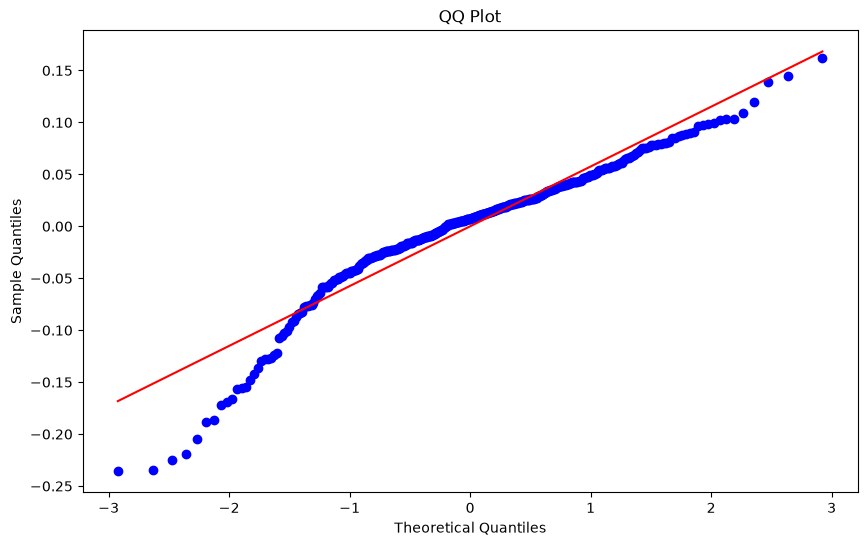

In [64]:
from scipy import stats
residuals = y_train - y_pred
fig = plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()